## Trends in Collision Types Among Young Drivers (Under 21): Pennsylvania Police Department Crash Data (2005–2024)”

![Photo from The Independent](img/youngdriverphoto.png) 

According to the Center for Disease Control (CDC), young drivers (16-19) have the highest risk of being involved in a vehicle crash than any other age group. In fact, it is the leading cause of death for this age range. With this alarming statistic it is beneficial to look into what, where, and when are the most common crashes affecting teen drivers occuring. 

Using Pensylvania data as a reference, we can understand more about what types of accidents and which locations teens should be cautious of.

------


In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import camelot
import calendar
import re
import matplotlib.pyplot as plt

In [2]:
crash_data = pd.read_csv('data/PDOT_crash_data_2005_2024.csv', low_memory=False)

In [3]:
crash_data.shape

(691069, 99)

In [4]:
crash_data.columns

Index(['CRN', 'ARRIVAL_TM', 'AUTOMOBILE_COUNT', 'BELTED_DEATH_COUNT',
       'BELTED_SUSP_SERIOUS_INJ_COUNT', 'BICYCLE_COUNT', 'BICYCLE_DEATH_COUNT',
       'BICYCLE_SUSP_SERIOUS_INJ_COUNT', 'BUS_COUNT', 'CHLDPAS_DEATH_COUNT',
       'CHLDPAS_SUSP_SERIOUS_INJ_COUNT', 'COLLISION_TYPE', 'COMM_VEH_COUNT',
       'CONS_ZONE_SPD_LIM', 'COUNTY', 'CRASH_MONTH', 'CRASH_YEAR',
       'DAY_OF_WEEK', 'DEC_LATITUDE', 'DEC_LONGITUDE', 'DISPATCH_TM',
       'DISTRICT', 'DRIVER_COUNT_16YR', 'DRIVER_COUNT_17YR',
       'DRIVER_COUNT_18YR', 'DRIVER_COUNT_19YR', 'DRIVER_COUNT_20YR',
       'DRIVER_COUNT_50_64YR', 'DRIVER_COUNT_65_74YR', 'DRIVER_COUNT_75PLUS',
       'EST_HRS_CLOSED', 'FATAL_COUNT', 'HEAVY_TRUCK_COUNT',
       'HORSE_BUGGY_COUNT', 'HOUR_OF_DAY', 'ILLUMINATION', 'INJURY_COUNT',
       'INTERSECTION_RELATED', 'INTERSECT_TYPE', 'LANE_CLOSED', 'LATITUDE',
       'LN_CLOSE_DIR', 'LOCATION_TYPE', 'LONGITUDE', 'MAX_SEVERITY_LEVEL',
       'MCYCLE_DEATH_COUNT', 'MCYCLE_SUSP_SERIOUS_INJ_COUNT',
 

In [5]:
driver_cols = [col for col in crash_data.columns if col.count('DRIVER_')]
driver_cols

['DRIVER_COUNT_16YR',
 'DRIVER_COUNT_17YR',
 'DRIVER_COUNT_18YR',
 'DRIVER_COUNT_19YR',
 'DRIVER_COUNT_20YR',
 'DRIVER_COUNT_50_64YR',
 'DRIVER_COUNT_65_74YR',
 'DRIVER_COUNT_75PLUS']

In [6]:
under_21 = crash_data['DRIVER_COUNT_16_20'] = crash_data[
    ['DRIVER_COUNT_16YR',
    'DRIVER_COUNT_17YR',
    'DRIVER_COUNT_18YR',
    'DRIVER_COUNT_19YR',
    'DRIVER_COUNT_20YR',]
].sum(axis=1)

In [7]:
under_21.sort_values().sample(15)

6354      0
173346    0
85275     0
445619    0
413647    1
650058    0
157155    0
230211    0
232726    0
216276    0
75835     0
419666    0
276985    0
503485    0
667006    0
dtype: int64

In [8]:
under_21_drivers = crash_data[under_21 == 1]
under_21_drivers

,CRN,ARRIVAL_TM,AUTOMOBILE_COUNT,BELTED_DEATH_COUNT,BELTED_SUSP_SERIOUS_INJ_COUNT,BICYCLE_COUNT,BICYCLE_DEATH_COUNT,BICYCLE_SUSP_SERIOUS_INJ_COUNT,BUS_COUNT,CHLDPAS_DEATH_COUNT,...,WORK_ZONE_TYPE,WZ_CLOSE_DETOUR,WZ_FLAGGER,WZ_LAW_OFFCR_IND,WZ_LN_CLOSURE,WZ_MOVING,WZ_OTHER,WZ_SHLDER_MDN,WZ_WORKERS_INJ_KILLED,DRIVER_COUNT_16_20
0,2005000003,NaN,1,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
9,2005001782,NaN,2,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
12,2005002108,NaN,3,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
13,2005002335,NaN,1,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
18,2005003022,NaN,2,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
666552,2024025173,1332.0,1,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
666592,2024025336,2014.0,1,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
666593,2024025337,332.0,0,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
666595,2024025339,1432.0,1,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [9]:
crash_data[['MUNICIPALITY','COUNTY', 'DISTRICT']]

,MUNICIPALITY,COUNTY,DISTRICT
0,9219,9,6
1,46224,46,6
2,46102,46,6
3,9415,9,6
4,9415,9,6
...,...,...,...
691064,15218,15,6
691065,9221,9,6
691066,67301,67,6
691067,67301,67,6


In [10]:
under_21_location = crash_data.loc[under_21_drivers.index, ['MUNICIPALITY','COUNTY','DISTRICT','COLLISION_TYPE']]
under_21_location

,MUNICIPALITY,COUNTY,DISTRICT,COLLISION_TYPE
0,9219,9,6,7
9,15253,15,6,1
12,15247,15,6,1
13,46209,46,6,4
18,15411,15,6,1
...,...,...,...,...
666552,15211,15,6,1
666592,23204,23,6,1
666593,23107,23,6,4
666595,23107,23,6,7


From this data chart we can already identify a pattern within young driver collisions. Many, if not all, collisions within this analysis take place in District 6 which "includes all of Chester County and southeastern Berks County, including the city of Reading" (https://houlahan.house.gov/about/our-district.htm). 

![Photo of District 6](img/d6-map.jpg) 


However, the location of crashes do vary by county, which is shown by the different codes that appear in the dataset. This tells us that even though District 6 encapsulates most of the analysis, there may be differences in traffic patterns, population, road design, or other factors that influence the frequency of collisions. For example, counties with more schools often have more student drivers and may raise the likelihood for them to crash into others or objects. Looking at these crash patterns can help identify where more saftey precautions, road signs, or eduction is needed.

In [11]:
under_21_drivers['COUNTY'].value_counts()

COUNTY
46    29599
9     23989
67    21426
15    19115
23    15551
Name: count, dtype: int64

The county's of the crashes that are represented in the sample are Montgomery County (46), Bucks County (9), Philadelphia County (67), Chester County (15), and Deleware County (23). Montgomery County is a suburb of Philadeliphia with a population of 54,353 15 to 19 year olds (https://www.neilsberg.com/insights/montgomery-county-pa-population-by-age/#google_vignette). 

As there are many teenagers who are eligible to drive in Montgomery County this could explain why there many more teen crashes that occur in the area. Additionally, this information conveys that less experienced drivers experience more difficulty when navigating more suburban areas. City planners or police officers may want to use this information to stay alert of potential teen accidents.

Text(0, 0.5, 'Number of Crashes')

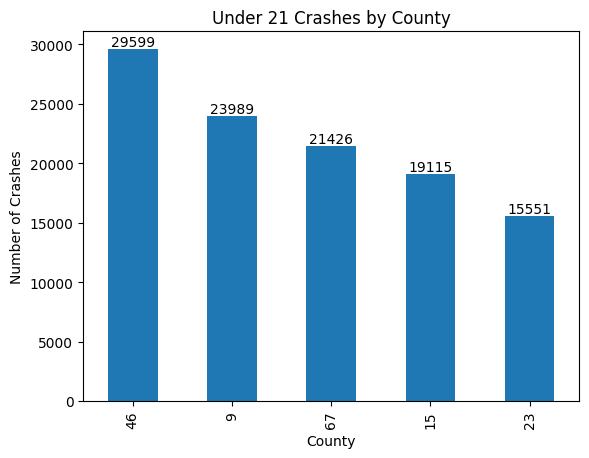

In [12]:
num_crashes_by_county = under_21_drivers['COUNTY'].value_counts().plot(kind='bar')

for bar in num_crashes_by_county.containers:
    num_crashes_by_county.bar_label(bar)

num_crashes_by_county.set_title("Under 21 Crashes by County")
num_crashes_by_county.set_xlabel("County")
num_crashes_by_county.set_ylabel("Number of Crashes")

While this plot describes how many crashes have occured by the county, this is still missing what types of crashes are most common among this age group. 

A close examination of Montgomery County as a sample can help identify the trends in crashes with more detail.

In [13]:
data_dictionary = pd.read_csv('data/data_dictionary.csv')

In [14]:
collision_labels = {
    0: 'Non-collision',
    1: 'Rear-end',
    2: 'Head-on',
    3: 'Backing',
    4: 'Angle',
    5: 'Sideswipe (same dir.)',
    6: 'Sideswipe (Opposite dir.)',
    7: 'Hit Fixed Object',
    8: 'Hit Non-Motorist',
    9: 'Other/Unknown (Expired)',
    98: 'Other',
    99: 'Unknown'
}

In [15]:
collision_labels

{0: 'Non-collision',
 1: 'Rear-end',
 2: 'Head-on',
 3: 'Backing',
 4: 'Angle',
 5: 'Sideswipe (same dir.)',
 6: 'Sideswipe (Opposite dir.)',
 7: 'Hit Fixed Object',
 8: 'Hit Non-Motorist',
 9: 'Other/Unknown (Expired)',
 98: 'Other',
 99: 'Unknown'}

From this bar chart it is shown that county number 46, which is

In [16]:
print(collision_labels)

{0: 'Non-collision', 1: 'Rear-end', 2: 'Head-on', 3: 'Backing', 4: 'Angle', 5: 'Sideswipe (same dir.)', 6: 'Sideswipe (Opposite dir.)', 7: 'Hit Fixed Object', 8: 'Hit Non-Motorist', 9: 'Other/Unknown (Expired)', 98: 'Other', 99: 'Unknown'}


In [17]:
crashes_in_mc = under_21_drivers[under_21_drivers['COUNTY'] == 46]
crashes_in_mc

,CRN,ARRIVAL_TM,AUTOMOBILE_COUNT,BELTED_DEATH_COUNT,BELTED_SUSP_SERIOUS_INJ_COUNT,BICYCLE_COUNT,BICYCLE_DEATH_COUNT,BICYCLE_SUSP_SERIOUS_INJ_COUNT,BUS_COUNT,CHLDPAS_DEATH_COUNT,...,WORK_ZONE_TYPE,WZ_CLOSE_DETOUR,WZ_FLAGGER,WZ_LAW_OFFCR_IND,WZ_LN_CLOSURE,WZ_MOVING,WZ_OTHER,WZ_SHLDER_MDN,WZ_WORKERS_INJ_KILLED,DRIVER_COUNT_16_20
13,2005002335,NaN,1,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
19,2005003031,NaN,2,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
38,2005005257,NaN,2,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
53,2005006064,NaN,2,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
68,2005009589,NaN,1,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
666134,2024023332,1128.0,1,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
666211,2024023681,2000.0,0,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
666306,2024024100,1522.0,0,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
666397,2024024543,1557.0,1,0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


In [18]:
mc_year_and_month = crashes_in_mc.groupby(['CRASH_YEAR','CRASH_MONTH','COLLISION_TYPE']).size()
mc_year_and_month

CRASH_YEAR  CRASH_MONTH  COLLISION_TYPE
2005        1            0                  2
                         1                 48
                         2                 14
                         4                 62
                         5                  6
                                           ..
2024        3            0                  1
                         1                  6
                         4                  7
                         5                  2
                         7                  2
Length: 1856, dtype: int64

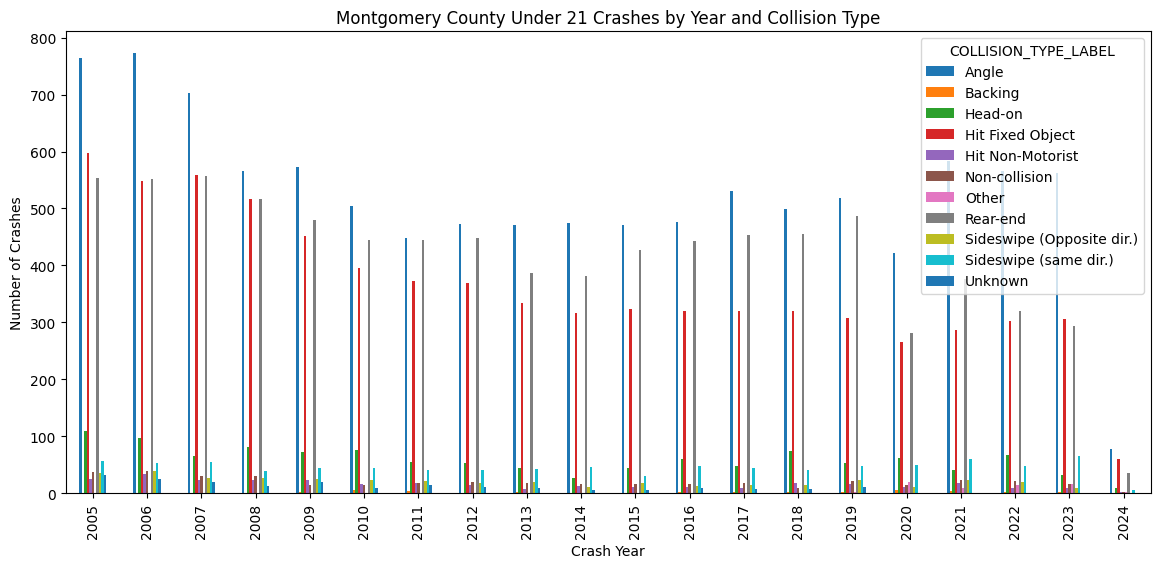

In [19]:
crashes_in_mc['COLLISION_TYPE_LABEL'] = crashes_in_mc['COLLISION_TYPE'].map(collision_labels)
mc_counts = crashes_in_mc.groupby(['CRASH_YEAR', 'COLLISION_TYPE_LABEL']).size().unstack(fill_value=0)

mc_counts.plot(kind='bar', figsize=(14,6))
plt.xlabel('Crash Year')
plt.ylabel('Number of Crashes')
plt.title('Montgomery County Under 21 Crashes by Year and Collision Type')
plt.show()

From examing the types of collisions that teens face we can draw multiple conclusions.

First, Angle collisions overall are the most common type of crash peaking in the mid-2000s and slightly declining over the past two decades. Angles crashes typically occur at intersections where the front on one vehicle hits the side of another, suggesting that young drivers face the most challenges when navigating intersections. Improvements to street signs or emphasis on intersection training within Philadelphia driving schools may be helpful in assisting younger divers.

Second, Rear-end crashes are the second most common which is another form of strike from one vehicle against another. These crashes are often the result of tailgating, slow reaction, or distraction. Since rear-end crashes have remained consistent throughout the 20 years this too signals that there may be a pattern within driving behaviors among younger drivers. Especially, since they experience overconfidence on the road and less hazard recognition, according to the CDC. (https://www.cdc.gov/teen-drivers/risk-factors/index.html)  

Third, crash counts have decline over the years. This may reflect existing improvements to roads, vehicles, and saftey measure to minimize car accidents. Further, many technological advancements have been made in regards to car functionality and design. This is said with the exception of 2020 which is when the COVID-19 outbreak was at its peak and the mandated lockdown likely led to less drivers being on the road. 

In [20]:
mc_year_and_month.idxmax()

(np.int64(2006), np.int64(6), np.int64(4))

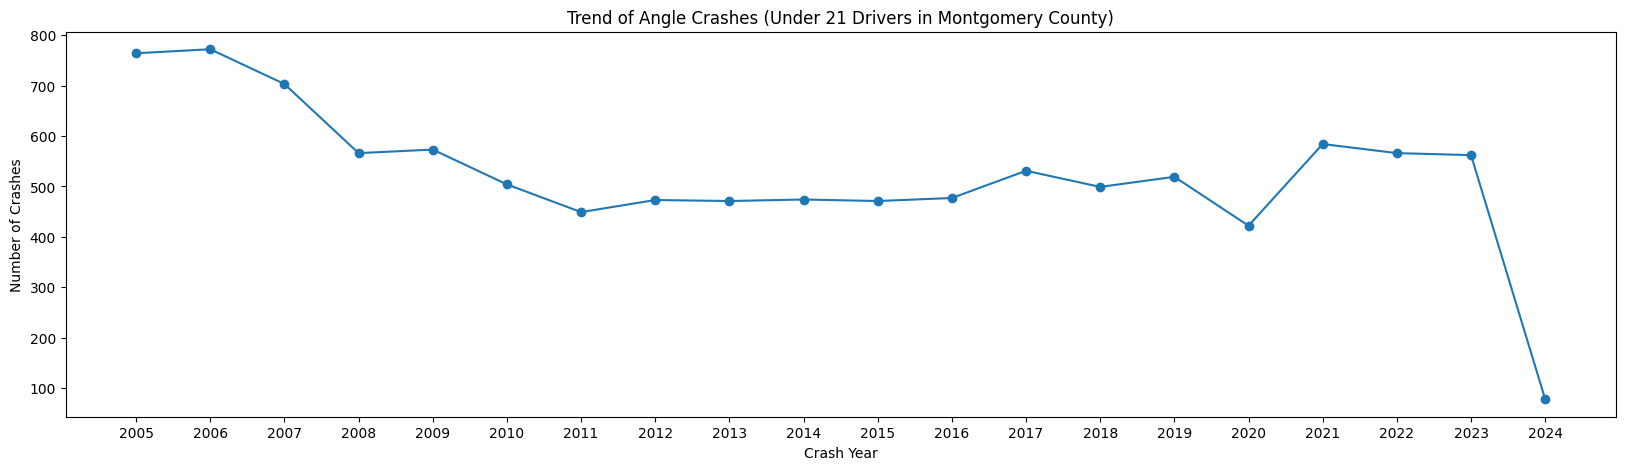

In [21]:
mc_counts['Angle'].plot(kind='line', marker='o', figsize=(20,5))

plt.xlabel('Crash Year')
plt.ylabel('Number of Crashes')
plt.title('Trend of Angle Crashes (Under 21 Drivers in Montgomery County)')

plt.xticks(mc_counts.index)
plt.show()

#### Conclusion

As angle crashes were the most common crash for under 21's in Montgomery County, this line plot reflects the trend represented by the larger bar chart. there is an evident decline from 2005 into the early 2010s where crashes went from around 800 to around 450 crashes. From 2011 to 2016 crashes slightly fluctuated but remaind mostly stable with in between 450 to 600 crashes each year. The sharp decrease in accidents in 2024 may be the result of an incomplete dataset.

Overall, this pattern highlights a potential issue of young drivers facing higher chances of risks when driving into intersections. Intersections require drivers to remain alert and minful of other vehicles. There is also a risk of harming pedestrians or bikers. With less experience on the road, stronger emphais on interecetion safety education and awarness during drivers-ed would play a significant role in preventing crash rates of younger drivers.